<a href="https://colab.research.google.com/github/loki-gif/case_study/blob/main/Unsupervised_learning_casestudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
import numpy as np
import pandas as pd

In [58]:
adult = pd.read_csv('/content/adult_dataset.csv')
adult.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [59]:
adult.shape

(48842, 15)

In [60]:
adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [61]:
adult = adult.drop_duplicates()

In [62]:
adult.isna().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [63]:
adult = adult.replace('?',np.nan,)

In [64]:
adult.isna().sum()

,0
age,2442
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


In [65]:
num_cols = ['age','hours-per-week']
cat_cols = ['workclass','occupation','native-country']

In [66]:
for i in num_cols :
  adult[i] = adult[i].fillna(adult[i].median())

In [67]:
for i in cat_cols :
  adult[i] = adult[i].fillna(adult[i].mode()[0])

In [68]:
adult.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [69]:
adult = adult.drop(columns = ['fnlwgt'])

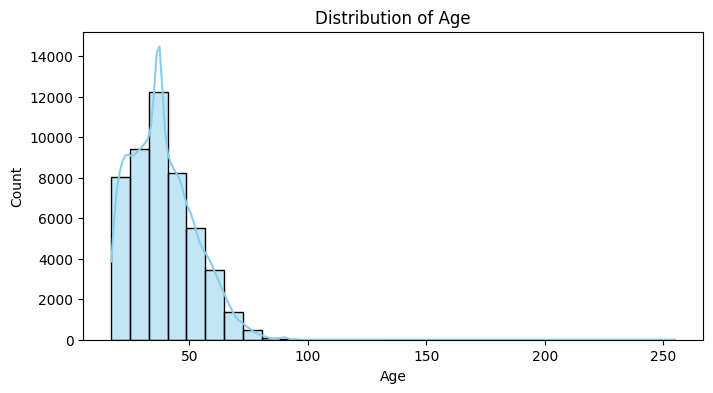

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of a single numerical feature
plt.figure(figsize=(8, 4))
sns.histplot(adult['age'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

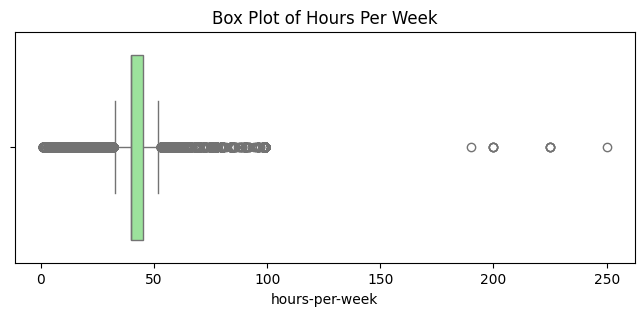

In [71]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=adult['hours-per-week'], color='lightgreen')
plt.title('Box Plot of Hours Per Week')
plt.show()

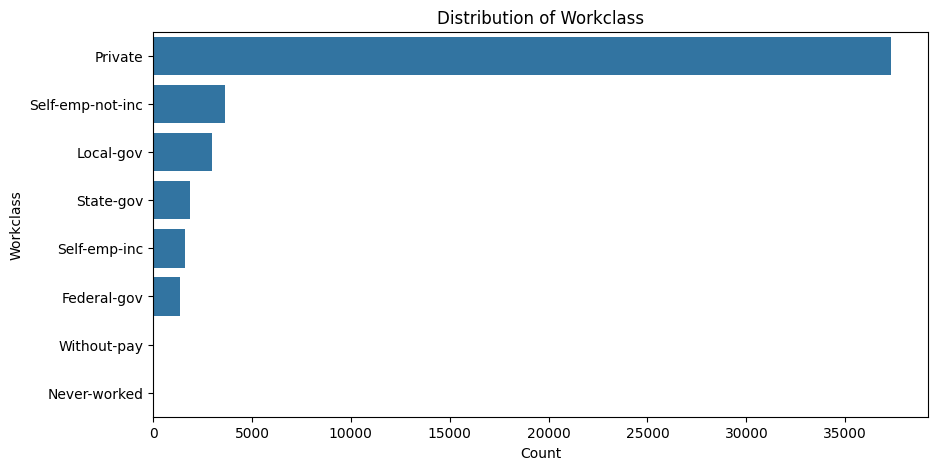

In [72]:
plt.figure(figsize=(10, 5))
# Horizontal count plot helps when category labels are long
sns.countplot(y='workclass', data=adult, order=adult['workclass'].value_counts().index)
plt.title('Distribution of Workclass')
plt.xlabel('Count')
plt.ylabel('Workclass')
plt.show()

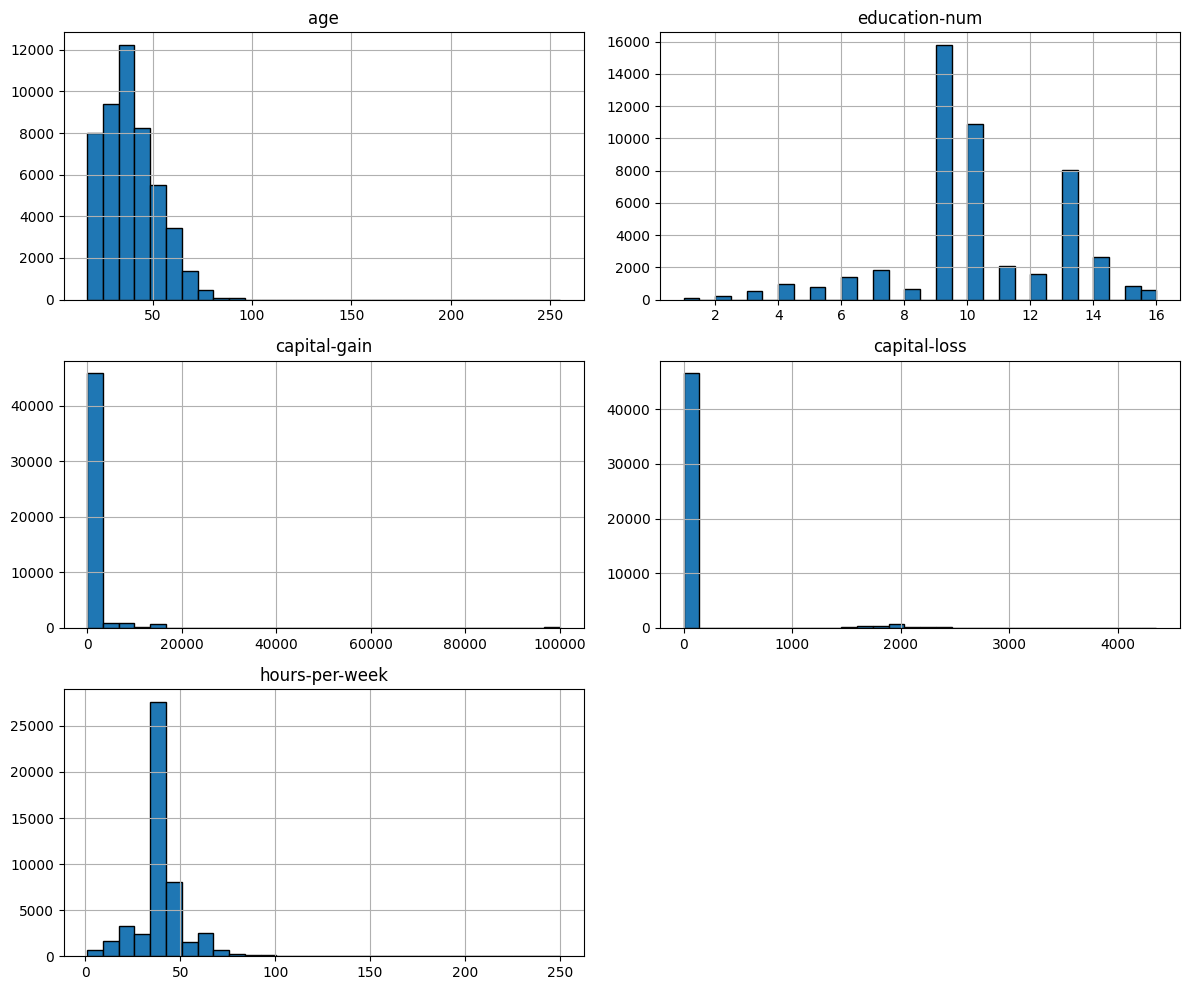

In [73]:
# Plot histograms for all numerical columns in a single grid
adult.hist(figsize=(12, 10), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()

In [74]:
num_cols1 = ['age','hours-per-week']

for i in num_cols1 :
  Q1 = adult[i].quantile(0.25)
  Q3 = adult[i].quantile(0.75)
  IQR = Q3-Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  outliers = adult[(adult[i] < lower) | (adult[i] > upper)]
  print(f"{i}:")
  print(f"Lower limit: {lower}")
  print(f"Upper limit: {upper}")
  print(f"Number of outliers: {len(outliers)}")
  print()

age:
Lower limit: -0.5
Upper limit: 75.5
Number of outliers: 363

hours-per-week:
Lower limit: 32.5
Upper limit: 52.5
Number of outliers: 12833



In [75]:
num_cols1 = ['age','hours-per-week']

for i in num_cols1 :
  Q1 = adult[i].quantile(0.25)
  Q3 = adult[i].quantile(0.75)
  IQR = Q3-Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  adult[i] = adult[i].clip(lower,upper)

In [76]:
import numpy as np

# Apply Log(1 + x) transformation to handle 0s safely
adult['capital-gain'] = np.log1p(adult['capital-gain'])
adult['capital-loss'] = np.log1p(adult['capital-loss'])

In [77]:
adult = adult.drop(columns = ['education-num'])

In [78]:
onehot_cols = [
    'workclass',
    'education',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country',
    'income'
]

adult = pd.get_dummies(
    adult, columns=onehot_cols, drop_first=True, dtype=int
)

print("Shape after One-Hot Encoding:", adult.shape)

Shape after One-Hot Encoding: (48826, 98)


In [79]:
adult.head()

,age,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,...,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,income_<=50K.,income_>50K,income_>50K.
0,39.0,7.684784,0.0,40.0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
1,50.0,0.000000,0.0,32.5,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
2,38.0,0.000000,0.0,40.0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,53.0,0.000000,0.0,40.0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,28.0,0.000000,0.0,40.0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [80]:
from sklearn.preprocessing import StandardScaler
std = StandardScaler()
adult_scaled = std.fit_transform(adult)
adult = pd.DataFrame(adult_scaled,columns = adult.columns)
adult

,age,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,...,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,income_<=50K.,income_>50K,income_>50K.
0,0.035123,2.844037,-0.221302,-0.187370,-0.254632,-0.013578,-1.802003,-0.185487,-0.284203,5.001278,...,-0.046644,-0.035368,-0.024378,-0.022634,0.296968,-0.041265,-0.021709,-0.584398,-0.437394,-0.292412
1,0.864064,-0.297971,-0.221302,-1.430414,-0.254632,-0.013578,-1.802003,-0.185487,3.518615,-0.199949,...,-0.046644,-0.035368,-0.024378,-0.022634,0.296968,-0.041265,-0.021709,-0.584398,-0.437394,-0.292412
2,-0.040236,-0.297971,-0.221302,-0.187370,-0.254632,-0.013578,0.554938,-0.185487,-0.284203,-0.199949,...,-0.046644,-0.035368,-0.024378,-0.022634,0.296968,-0.041265,-0.021709,-0.584398,-0.437394,-0.292412
3,1.090139,-0.297971,-0.221302,-0.187370,-0.254632,-0.013578,0.554938,-0.185487,-0.284203,-0.199949,...,-0.046644,-0.035368,-0.024378,-0.022634,0.296968,-0.041265,-0.021709,-0.584398,-0.437394,-0.292412
4,-0.793819,-0.297971,-0.221302,-0.187370,-0.254632,-0.013578,0.554938,-0.185487,-0.284203,-0.199949,...,-0.046644,-0.035368,-0.024378,-0.022634,-3.367365,-0.041265,-0.021709,-0.584398,-0.437394,-0.292412
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48821,0.035123,-0.297971,-0.221302,-0.850327,-0.254632,-0.013578,0.554938,-0.185487,-0.284203,-0.199949,...,-0.046644,-0.035368,-0.024378,-0.022634,0.296968,-0.041265,-0.021709,1.711163,-0.437394,-0.292412
48822,1.919081,-0.297971,-0.221302,-0.187370,-0.254632,-0.013578,0.554938,-0.185487,-0.284203,-0.199949,...,-0.046644,-0.035368,-0.024378,-0.022634,0.296968,-0.041265,-0.021709,1.711163,-0.437394,-0.292412
48823,-0.040236,-0.297971,-0.221302,1.470021,-0.254632,-0.013578,0.554938,-0.185487,-0.284203,-0.199949,...,-0.046644,-0.035368,-0.024378,-0.022634,0.296968,-0.041265,-0.021709,1.711163,-0.437394,-0.292412
48824,0.411914,3.220061,-0.221302,-0.187370,-0.254632,-0.013578,0.554938,-0.185487,-0.284203,-0.199949,...,-0.046644,-0.035368,-0.024378,-0.022634,0.296968,-0.041265,-0.021709,1.711163,-0.437394,-0.292412


In [81]:
adult.corr()

,age,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,...,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,income_<=50K.,income_>50K,income_>50K.
age,1.000000,0.121239,0.051819,0.090607,0.054782,-0.018282,-0.179598,0.096326,0.135526,0.012389,...,-0.004646,-0.011604,-0.000094,0.001204,0.011140,-0.013537,0.003323,-0.067782,0.175309,0.119486
capital-gain,0.121239,1.000000,-0.065942,0.099486,0.006403,-0.004046,-0.051377,0.076365,0.020345,-0.005820,...,-0.001833,0.002176,-0.004207,-0.003764,0.016559,0.003029,0.006689,-0.095952,0.226664,0.149010
capital-loss,0.051819,-0.065942,1.000000,0.056269,0.012030,-0.003005,-0.032895,0.032823,0.013523,-0.000327,...,0.002230,0.003251,-0.001525,0.003723,0.012428,0.000283,-0.004804,-0.042693,0.109270,0.070078
hours-per-week,0.090607,0.099486,0.056269,1.000000,-0.000554,-0.012546,-0.103177,0.129246,0.091609,-0.024276,...,0.013140,-0.000188,0.005951,-0.002290,0.021232,-0.013005,0.003285,-0.085920,0.206378,0.135224
workclass_Local-gov,0.054782,0.006403,0.012030,-0.000554,1.000000,-0.003457,-0.458848,-0.047231,-0.072367,-0.050913,...,-0.011877,-0.006581,-0.002692,0.001809,0.031052,-0.004270,-0.001581,-0.013145,0.025325,0.021245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
native-country_Vietnam,-0.013537,0.003029,0.000283,-0.013005,-0.004270,-0.000560,0.007666,-0.004882,0.001507,-0.008251,...,-0.001925,-0.001459,-0.001006,-0.000934,-0.138955,1.000000,-0.000896,-0.006996,-0.011279,-0.008375
native-country_Yugoslavia,0.003323,0.006689,-0.004804,0.003285,-0.001581,-0.000295,-0.001301,0.001237,0.008188,-0.004341,...,-0.001013,-0.000768,-0.000529,-0.000491,-0.073102,-0.000896,1.000000,-0.001853,0.005929,0.000660
income_<=50K.,-0.067782,-0.095952,-0.042693,-0.085920,-0.013145,-0.001008,0.036304,-0.043637,-0.001958,-0.001429,...,0.003045,-0.011352,0.005051,0.003399,-0.007862,-0.006996,-0.001853,1.000000,-0.255612,-0.170885
income_>50K,0.175309,0.226664,0.109270,0.206378,0.025325,-0.005939,-0.093986,0.106143,0.021426,0.010321,...,-0.003623,0.014535,-0.003794,-0.004968,0.028097,-0.011279,0.005929,-0.255612,1.000000,-0.127899


In [82]:
from sklearn.decomposition import PCA

pca_model = PCA(n_components = 25)
adult_pca = pca_model.fit_transform(adult)

In [83]:
explained_variance = pca_model.explained_variance_ratio_
explained_variance

array([0.03716642, 0.02601161, 0.0220566 , 0.0205344 , 0.01863755,
       0.01751818, 0.01585604, 0.01489584, 0.0144167 , 0.01341227,
       0.01312462, 0.01255934, 0.01229437, 0.01202187, 0.01195063,
       0.01182863, 0.01166942, 0.0115291 , 0.01148985, 0.01136917,
       0.0112919 , 0.01114188, 0.01107542, 0.01097119, 0.01094043])

K MEANS CLUSTERING

In [84]:
from sklearn.cluster import KMeans

wcss_list = []
for i in range(1,20) :
  kmeans = KMeans(n_clusters = i,init = 'k-means++',random_state = 42)
  kmeans.fit(adult_pca)
  wcss_list.append(kmeans.inertia_)
wcss_list

[1798008.4677717243,
 1659887.3670085815,
 1606238.0303234134,
 1529737.9768748523,
 1481061.103775812,
 1428932.1684041312,
 1380035.7937420753,
 1361353.2150545793,
 1297000.101401279,
 1270934.7940474078,
 1220736.1408589187,
 1183497.4490462109,
 1171061.8586103173,
 1146727.9704208516,
 1117635.8902139068,
 1108294.6269493848,
 1084259.1312325697,
 1065751.9377686616,
 1029987.1072675303]

Text(0, 0.5, 'WCSS')

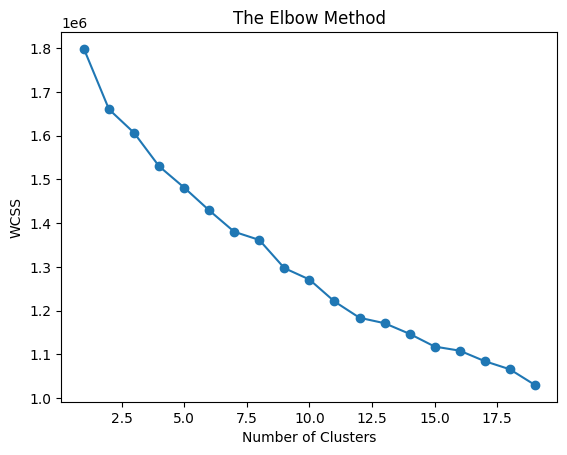

In [85]:
plt.plot(range(1,20),wcss_list,marker = 'o')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

In [86]:
from sklearn.metrics import silhouette_score

for k in range(3,7):
    model = KMeans(
        n_clusters=k, init="k-means++", random_state=42, n_init=10
    )
    labels = model.fit_predict(adult_pca)
    score = silhouette_score(adult_pca, labels)
    print(f"Silhouette Score for k={k}: {score:.4f}")

Silhouette Score for k=3: 0.0891
Silhouette Score for k=4: 0.0900
Silhouette Score for k=5: 0.0773
Silhouette Score for k=6: 0.0788


In [87]:
kmeans_model = KMeans(n_clusters = 4,init = 'k-means++',random_state = 42,n_init = 10)
y_predict = kmeans_model.fit_predict(adult_pca)
y_predict

array([1, 3, 1, ..., 3, 1, 3], dtype=int32)

In [88]:
data = pd.DataFrame(adult_pca,columns = ['p1','p2','p3','p4','p5','p6','p7','p8','p9','p10','p11','p12','p13','p14','p15','p16','p17','p18','p19','p20','p21','p22','p23','p24','p25'])

In [89]:
data['kmeans_cluster'] = y_predict
data.head()

,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,...,p17,p18,p19,p20,p21,p22,p23,p24,p25,kmeans_cluster
0,0.289891,0.840578,-2.268565,-1.286982,1.382090,-1.342741,0.973887,1.134775,0.385252,0.686101,...,-0.253490,-0.778810,-0.664242,2.007696,1.835865,1.494904,-0.857986,0.614923,0.390761,1
1,2.464891,0.333592,-0.646760,-0.132012,0.582812,-1.508231,0.356350,-0.412566,-1.819096,-0.345021,...,-1.035801,-0.634837,-0.463311,0.536402,-0.713482,0.180254,-0.985118,0.767545,0.144249,3
2,-0.750134,0.808093,1.335203,0.457445,-0.093454,0.134614,1.444565,0.494903,1.443105,0.586091,...,0.033370,0.045886,-0.071168,0.089165,0.432289,-0.789398,-0.040574,0.583452,0.717840,1
3,-0.531562,-1.129452,0.526283,1.282662,-3.084548,-0.204771,-1.165629,1.963793,0.706929,-1.501625,...,-0.472191,-0.353671,-0.423998,0.953249,-0.501521,-0.920615,0.274732,-0.187036,0.209798,2
4,-0.100940,-4.375668,-1.088842,-0.072320,0.320917,1.939103,-3.473725,0.559699,-0.749777,0.117522,...,1.798859,-1.761803,2.315120,-1.044384,0.621782,-0.474440,-0.445565,0.879389,-2.500001,0


In [90]:
data['kmeans_cluster'].value_counts()

,count
kmeans_cluster,
3,20329
1,19779
2,4958
0,3760


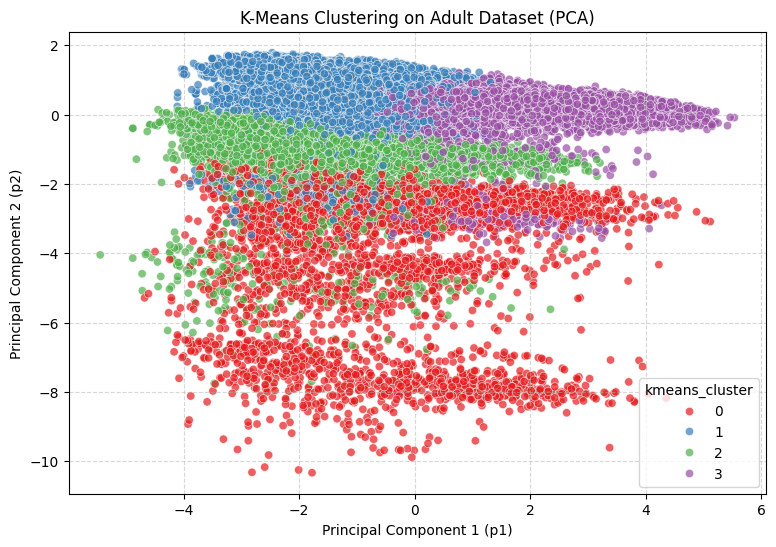

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))

# Plot Principal Component 1 vs Principal Component 2
sns.scatterplot(
    x='p1',
    y='p2',
    data=data,
    hue='kmeans_cluster',
    palette='Set1',
    alpha=0.7,
)

plt.xlabel('Principal Component 1 (p1)')
plt.ylabel('Principal Component 2 (p2)')
plt.title('K-Means Clustering on Adult Dataset (PCA)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

The K-Means clustering algorithm grouped the Adult dataset into four distinct clusters based on similarities in demographic and employment-related features. The PCA visualization shows that the clusters are reasonably well separated, indicating meaningful patterns in the data. By comparing these clusters with the income column, different socioeconomic groups can be identified. These insights can help policymakers and organizations understand population segments and design targeted initiatives such as upskilling programs for low-income groups, tax planning for higher-income groups, and financial aid or inclusion programs for economically disadvantaged individuals.

AGGLOMERATIVE CLUSTERING

In [92]:
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage

# Use NumPy's random choice to pick 1000 indices
np.random.seed(46)
sample_indices = np.random.choice(adult_pca.shape[0], size=1000, replace=False)
adult_samples = adult_pca[sample_indices]

# Compute linkage
mergings = linkage(adult_samples, method='ward')

Text(0, 0.5, 'Euclidean Distance')

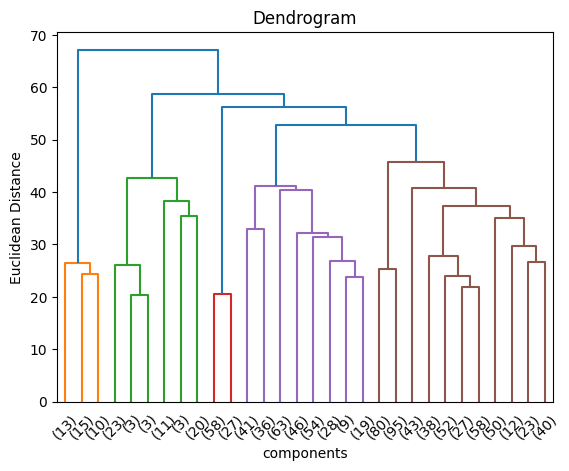

In [93]:
from scipy.cluster.hierarchy import dendrogram,linkage
mergings = linkage(adult_samples,method='ward')
dendrogram(mergings,truncate_mode ='lastp', p = 30)
plt.title('Dendrogram')
plt.xlabel('components')
plt.ylabel('Euclidean Distance')

In [94]:
from scipy.cluster.hierarchy import fcluster
agglo_cluster = fcluster(mergings,50,criterion = 'distance')
agglo_cluster

array([5, 4, 3, 5, 4, 4, 5, 4, 5, 4, 3, 2, 5, 5, 2, 5, 2, 5, 5, 4, 4, 4,
       4, 1, 4, 5, 4, 2, 5, 5, 5, 3, 5, 4, 4, 5, 5, 5, 5, 5, 4, 5, 5, 5,
       5, 4, 5, 3, 4, 4, 4, 1, 5, 2, 5, 5, 5, 4, 5, 5, 4, 5, 5, 5, 4, 5,
       1, 5, 5, 5, 5, 4, 4, 5, 4, 5, 1, 5, 5, 5, 5, 3, 4, 5, 5, 5, 2, 4,
       5, 4, 5, 4, 5, 5, 2, 5, 4, 5, 2, 5, 5, 4, 3, 5, 5, 5, 5, 5, 5, 2,
       4, 4, 4, 5, 4, 5, 4, 5, 5, 3, 3, 4, 4, 5, 5, 5, 5, 5, 3, 2, 5, 3,
       5, 5, 4, 5, 4, 5, 2, 5, 3, 4, 5, 5, 1, 5, 5, 5, 3, 4, 4, 4, 5, 5,
       2, 5, 5, 3, 1, 5, 4, 5, 5, 4, 5, 5, 4, 4, 4, 5, 4, 4, 4, 2, 5, 5,
       5, 4, 5, 5, 5, 5, 5, 4, 5, 5, 5, 3, 5, 4, 2, 5, 4, 5, 5, 3, 4, 4,
       5, 4, 5, 4, 4, 4, 4, 5, 5, 4, 5, 5, 5, 5, 5, 3, 5, 3, 4, 4, 1, 4,
       3, 3, 5, 2, 4, 5, 4, 5, 5, 4, 5, 4, 5, 5, 3, 5, 4, 5, 3, 5, 4, 4,
       4, 4, 4, 5, 1, 5, 5, 4, 5, 5, 4, 5, 2, 5, 5, 4, 4, 5, 4, 5, 3, 4,
       4, 5, 5, 5, 5, 5, 4, 5, 5, 5, 3, 5, 5, 5, 5, 2, 3, 4, 5, 5, 4, 5,
       5, 3, 2, 5, 4, 5, 5, 4, 4, 4, 4, 4, 3, 4, 3,

In [96]:
import pandas as pd

# 1. Convert NumPy array to DataFrame
adult_samples_df = pd.DataFrame(
    adult_samples,
    columns=[f'p{i+1}' for i in range(adult_samples.shape[1])]
)

# 2. Add the cluster labels column
adult_samples_df['agglo_cluster'] = agglo_cluster

# 3. View the result
adult_samples_df.head()

,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,...,p17,p18,p19,p20,p21,p22,p23,p24,p25,agglo_cluster
0,-2.849346,1.469672,-0.111127,-1.669797,-0.232973,0.019622,-1.375567,-0.825460,-0.852154,-0.181744,...,-0.016793,0.083704,0.000564,-0.375263,0.127933,-0.178131,-0.252442,0.339369,0.467520,5
1,2.483882,0.141091,-0.369214,-1.567756,-0.066292,0.840380,-0.717588,0.452510,2.422522,-3.103355,...,0.384721,3.281788,1.839387,-0.615836,1.567307,1.272962,-0.171586,1.099974,-0.904899,4
2,-2.608810,-0.441282,-0.945535,1.377128,-1.837466,-0.140288,1.513036,1.731563,0.437369,0.512823,...,0.144642,0.167041,-0.010034,0.576939,1.606127,-0.905344,1.248699,0.654947,-0.791424,3
3,0.576963,0.590894,2.231823,0.944981,-1.073303,-0.292782,0.651781,-0.816192,0.968643,0.696587,...,0.047729,0.481467,-0.270503,0.386767,-0.728926,0.091595,-1.113051,-0.505783,-0.005444,5
4,0.676185,0.336647,-1.632692,0.370007,0.255659,-0.767211,-3.092037,-2.395713,-1.021436,1.364949,...,-0.905186,-0.811009,0.116703,1.872677,0.691001,0.015767,-0.754999,0.309806,-0.044735,4


In [98]:
adult_samples_df['agglo_cluster'].value_counts()

,count
agglo_cluster,
5,518
4,296
3,85
2,63
1,38


Text(0.5, 1.0, 'Agglomarative Clustering')

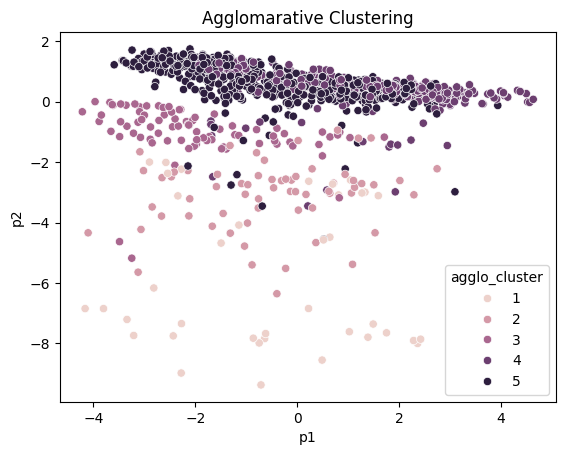

In [99]:
import seaborn as sns
sns.scatterplot(x = 'p1',
                y = 'p2',
                data = adult_samples_df,
                hue ='agglo_cluster')
plt.xlabel("p1")
plt.ylabel('p2')
plt.title('Agglomarative Clustering')

The Agglomerative Clustering algorithm grouped the Adult dataset into five hierarchical clusters based on the similarity between data points. The PCA visualization shows that the clusters capture different demographic and employment patterns, although some overlap exists due to the complexity of the data. By comparing these clusters with the income column, different socioeconomic groups can be identified. These insights can support decision-making by identifying groups that may benefit from upskilling programs, financial assistance, employment opportunities, or tax-related policies. Overall, Agglomerative Clustering provides a hierarchical view of the data and helps uncover meaningful relationships among similar individuals.